In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('student-mat.csv',sep = ';')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print(df.shape)
print(df.columns.tolist())

(395, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

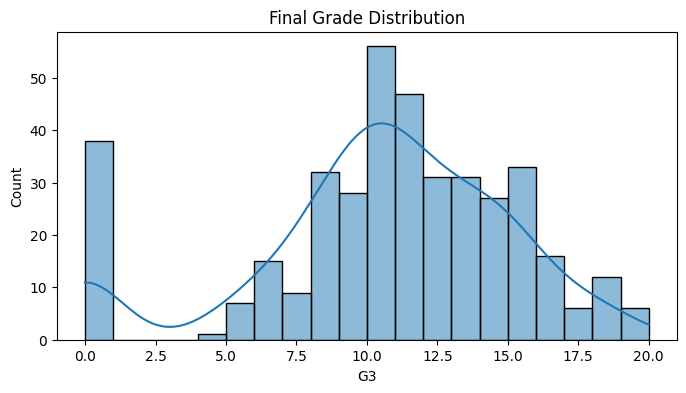

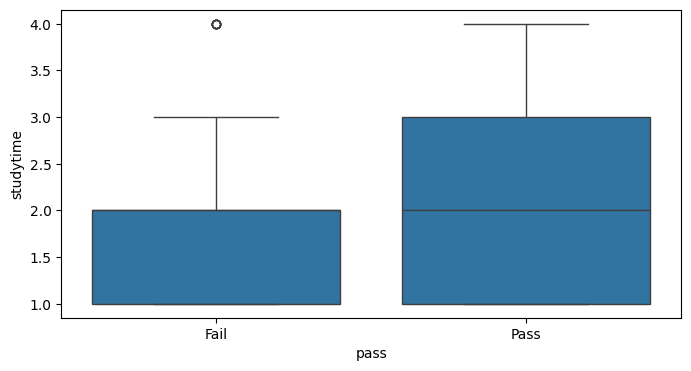

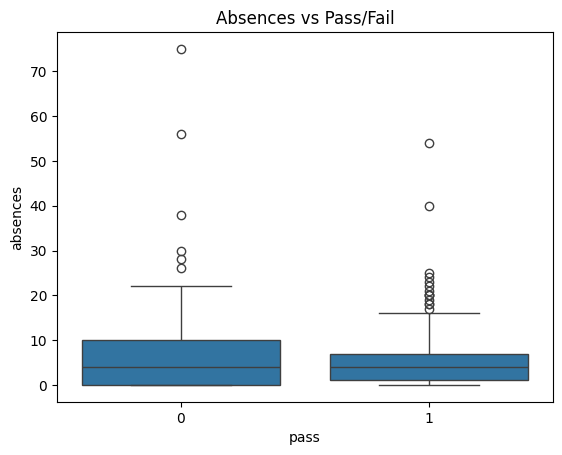

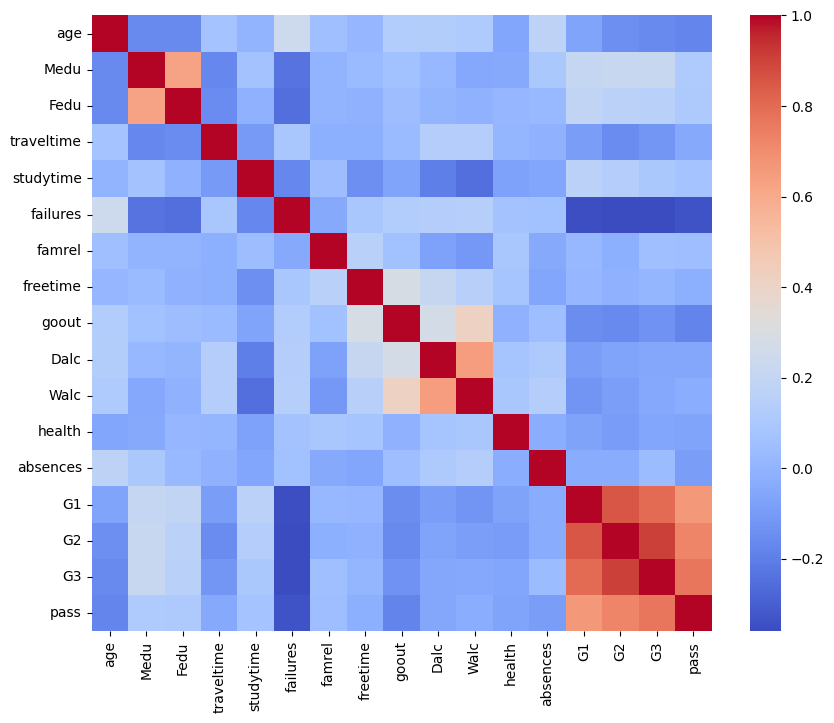

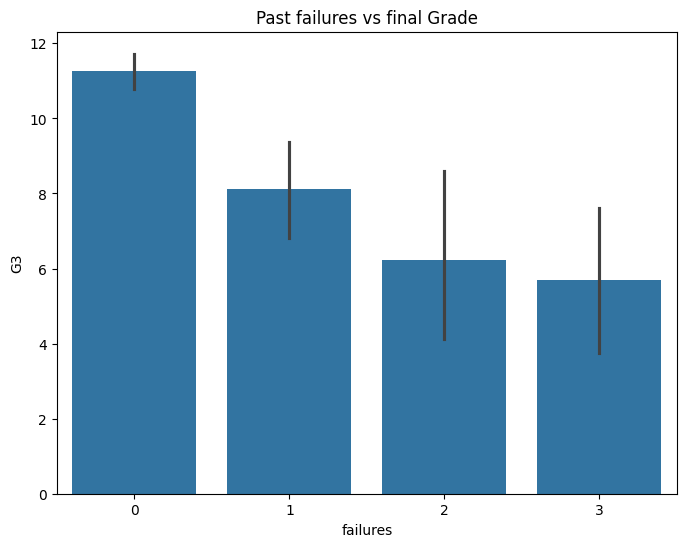

In [7]:
plt.figure(figsize = (8,4)) 
#creates a blank canvas for chart and of width 8 and height 4
sns.histplot(df['G3'],bins = 20,kde = True)
#draws a histogram,using final grade column and splits the data into 20 bars and 
#'kde' helps having smooth curve on the top
plt.title('Final Grade Distribution') 
plt.savefig('chart1.png') 
#saves the chart as an image file
plt.show()


df['pass'] = df['G3'].apply(lambda x : 1 if x >=10 else 0)
#creates a new column pass that only has values of G3 over 10
plt.figure(figsize = (8,4))
#figure size for boxplot
sns.boxplot(x = 'pass',y = 'studytime',data = df) 
#x axis shows pass or fail and y shows study time
plt.xticks([0,1],['Fail','Pass'])
#0 is shown as fail and 1 and pass
plt.savefig('chart2.png')
plt.show()

sns.boxplot(x = 'pass',y = 'absences',data = df)
# i am checking if the students who are failing more are absentees
plt.title('Absences vs Pass/Fail')
df.select_dtypes(include = 'number')
#filters only numerical based columns
plt.savefig('chart3.png')
plt.show()


plt.figure(figsize = (10,8))
numeric_df = df.select_dtypes(include = 'number')
sns.heatmap(numeric_df.corr(),cmap = 'coolwarm')
plt.savefig('chart4.png')
plt.show()

plt.figure(figsize = (8,6))
sns.barplot(x = 'failures',y = 'G3',data =df)
plt.title('Past failures vs final Grade')
plt.savefig('chart5.png')
plt.show()          

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report
import pickle

In [9]:
features = ['studytime', 'absences', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher']
df_model = df[features + ['pass']].copy() 
#copy() makes a fresh model so we dont change the original df

In [10]:
le = LabelEncoder()
#using LabelEncoder Library
yes_no_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher']

for col in yes_no_cols:
    df_model[col] = le.fit_transform(df_model[col])
    # we are actually converting yes and no to 1 and 0

In [11]:
X = df_model[features]
#input data
Y = df_model['pass']
#output column
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)
print(f"Training sample:{len(X_train)}")
print(f"Test sample:{len(X_test)}")
#we are taking training sample as 316 and test sample as 79 sets

Training sample:316
Test sample:79


In [12]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test,Y_pred)

In [14]:
print(f"accuracy is : {accuracy*100:.2f}%")
#calcurating the accuracy but only till 2 decimal points

accuracy is : 74.68%


In [15]:
print("\nDetailed report:")
print(classification_report(Y_test,Y_pred,target_names = ['Pass','Fail']))


Detailed report:
              precision    recall  f1-score   support

        Pass       0.77      0.37      0.50        27
        Fail       0.74      0.94      0.83        52

    accuracy                           0.75        79
   macro avg       0.76      0.66      0.67        79
weighted avg       0.75      0.75      0.72        79



In [16]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
# 'wb' means write in binary mode (required for pickle)
# pickle.dump() serializes the model object and writes it to model.pkl

print("Model saved as model.pkl")

Model saved as model.pkl
